# CNN - Convolutional Neural Network
In this notebook, we're going to be building a convolutional neural network (CNN) to classify images of clothing from the Fashion MNIST dataset.
We'll be using the Keras API, which is a high-level neural networks API, written in Python and capable of running on top of TensorFlow. Keras makes it easy to build and train deep learning models.
We'll start by importing the necessary libraries and loading the Fashion MNIST dataset, which is a collection of 70,000 grayscale images of 10 different categories of clothing items. Each image is 28x28 pixels in size.
We'll then preprocess the data, build our CNN model, compile it, and train it on the training data. Finally, we'll evaluate the model's performance on the test data and make predictions.
## What is a Convolutional Neural Network (CNN)?
A Convolutional Neural Network (CNN) is a type of deep learning model that is particularly effective for image recognition and classification tasks. CNNs are designed to automatically and adaptively learn spatial hierarchies of features from input images. They consist of several layers, including convolutional layers, pooling layers, and fully connected layers.
- **Convolutional Layers**: These layers apply a set of filters to the input image
to create feature maps. Each filter detects specific features such as edges, textures, or patterns in the image.
- **Pooling Layers**: These layers reduce the spatial dimensions of the feature maps, which helps to decrease the computational load and prevent overfitting. Common pooling operations include max pooling and average pooling.
- **Fully Connected Layers**: These layers are typically found at the end of the CNN and are used to make the final classification based on the features extracted by the convolutional and pooling layers.
CNNs have been widely used in various applications, including image classification, object detection, and evenq video analysis, due to their ability to effectively capture spatial and temporal dependencies in data.  


## Architecture of a CNN
The architecture of a CNN typically consists of the following layers:
1. **Input Layer**: This layer receives the input image data. For example, for a 28x28 grayscale image, the input layer would have a shape of (28, 28, 1).
2. **Convolutional Layer**: This layer applies a set of filters to the input image to create feature maps. Each filter detects specific features such as edges, textures, or patterns in the image.
3. **Activation Layer**: This layer applies an activation function (e.g., ReLU) to introduce non-linearity into the model, allowing it to learn more complex patterns.
4. **Pooling Layer**: This layer reduces the spatial dimensions of the feature maps, which helps to decrease the computational load and prevent overfitting. Common pooling operations include max pooling and average pooling.
5. **Fully Connected Layer**: This layer is typically found at the end of the CNN and is used to make the final classification based on the features extracted by the convolutional and pooling layers.
6. **Output Layer**: This layer produces the final output of the model, which is typically a probability distribution over the classes for classification tasks.
7. **Output activation**: For multi-class classification, the output layer often uses a softmax activation function to convert the output into probabilities for each class.
8. **Hidden Layers**: In addition to the convolutional and pooling layers, CNNs may also include hidden layers that further process the features extracted from the input data before making a final prediction. usually ReLU activation is used in hidden layers to introduce non-linearity and allow the model to learn more complex patterns in the data.

In [ ]:
""" Example Code: Architecture of a CNN
1. Create a CNN model using Keras Sequential API.
cnn_model = keras.Sequential([
    tf.keras.layers.Conv2D(fliters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2),
    padding='valid'),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])
2. Compile the model with an appropriate loss function and optimizer.
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
3. Train the model on your dataset.
cnn_model.fit(train_data, train_labels, epochs=10, validation_data=(test_data, test_labels))
4. Evaluate the model's performance on the test set.
test_loss, test_acc = cnn_model.evaluate(test_data, test_labels)



"""

In [2]:
!pip install zipfile

ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for zipfile


In [5]:
import zipfile
import os
import urllib.request

# 1. Download the data using a Python-native method
url = "https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip"
filename = "pizza_steak.zip"

print(f"Downloading {filename}...")
urllib.request.urlretrieve(url, filename)

# 2. Unzip the data
print("Unzipping data...")
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall()

# 3. Check the data directories
# Note: The zip usually extracts into a folder named "pizza_steak" 
# Verify your directory name below matches the extracted folder
target_dir = "pizza_steak" 

for dirpath, dirnames, filenames in os.walk(target_dir):
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in "{dirpath}".')

Unzipping data...
There are 2 directories and 0 images in "pizza_steak".
There are 2 directories and 0 images in "pizza_steak\test".
There are 0 directories and 250 images in "pizza_steak\test\pizza".
There are 0 directories and 250 images in "pizza_steak\test\steak".
There are 2 directories and 0 images in "pizza_steak\train".
There are 0 directories and 750 images in "pizza_steak\train\pizza".
There are 0 directories and 750 images in "pizza_steak\train\steak".


## Inspect the data ( becoming one with it)
A very important step in any machine learning project is to understand the data you're working with. This involves inspecting the data, visualizing it, and getting a sense of its structure and characteristics. For image data, this often includes looking at sample images, understanding the distribution of classes, and checking for any anomalies or patterns in the data.


In [6]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [10]:
!dir pizza_steak

 Volume in drive C is Acer
 Volume Serial Number is 1CE4-B9D7

 Directory of c:\vs code\tensorflow\pizza_steak

26-04-2026  06:15 PM    <DIR>          .
26-04-2026  06:15 PM    <DIR>          ..
26-04-2026  06:15 PM    <DIR>          test
26-04-2026  06:15 PM    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  82,342,940,672 bytes free


In [11]:
# walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in "{dirpath}".')

There are 2 directories and 0 images in "pizza_steak".
There are 2 directories and 0 images in "pizza_steak\test".
There are 0 directories and 250 images in "pizza_steak\test\pizza".
There are 0 directories and 250 images in "pizza_steak\test\steak".
There are 2 directories and 0 images in "pizza_steak\train".
There are 0 directories and 750 images in "pizza_steak\train\pizza".
There are 0 directories and 750 images in "pizza_steak\train\steak".


In [14]:
# To visualize our images,first lets get the class names programmatically
import pathlib
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*') if item.is_dir()])) # Created a lsit of class_names from the subdirectories of the training data directory and sorted them alphabetically
print(f'Class names: {class_names}')

Class names: ['pizza' 'steak']


In [16]:
# Let's visualize our images
import matplotlib.image as mpimg
import random
def view_random_image(target_dir, target_class):
    target_folder = target_dir + "/" + target_class
    random_image = random.sample(os.listdir(target_folder), 1)  # get a random image from the target class folder
    img = mpimg.imread(target_folder + "/" + random_image[0])  # read the image
    plt.imshow(img)  # plot the image
    plt.title(f'Class: {target_class}')  # add title to the plot
    plt.axis('off')  # turn off axes
    print(f'Image shape: {img.shape}')  # print the shape of the image


Image shape: (512, 512, 3)


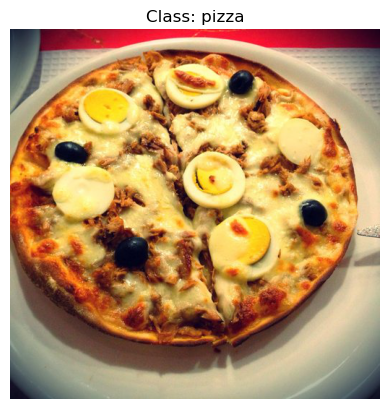

In [17]:
view_random_image(target_dir="pizza_steak/train", target_class="pizza")

Image shape: (341, 512, 3)


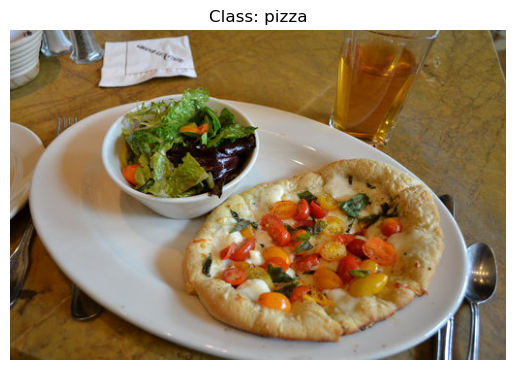

In [27]:
view_random_image(target_dir="pizza_steak/test", target_class="pizza")

In [33]:
tf.constant(img)

<tf.Tensor: shape=(384, 512, 3), dtype=uint8, numpy=
array([[[  0,   7,  24],
        [  0,   7,  20],
        [  0,   4,  13],
        ...,
        [ 26,  48,  35],
        [ 31,  58,  23],
        [ 21,  51,   1]],

       [[  0,   2,   4],
        [  0,   1,   7],
        [  0,   3,  18],
        ...,
        [ 23,  43,  32],
        [ 29,  53,  31],
        [ 27,  52,  23]],

       [[  0,   2,   0],
        [  1,   2,   0],
        [  1,   0,  11],
        ...,
        [ 18,  35,  27],
        [ 22,  38,  37],
        [ 25,  43,  45]],

       ...,

       [[209, 210, 178],
        [239, 238, 217],
        [255, 255, 248],
        ...,
        [ 71,  42,  34],
        [ 79,  46,  39],
        [ 93,  58,  54]],

       [[171, 167, 138],
        [189, 185, 160],
        [232, 229, 212],
        ...,
        [ 86,  49,  22],
        [103,  61,  39],
        [107,  61,  45]],

       [[167, 159, 157],
        [147, 140, 130],
        [187, 182, 163],
        ...,
        [ 87,  45,   

In [34]:
# View the image Shape
img.shape

(384, 512, 3)

In [35]:
img//255.0

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], shape=(384, 512, 3))

## Building a CNN model

In [36]:
# Normalize the image data to be between 0 and 1
img = img / 255.0

In [38]:
# An end-to-end example of building a CNN model for image classification using TensorFlow and Keras.

In [42]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Set up data generators
#set the seed
tf.random.set_seed(42)
# Preprocess the data (get it ready for our model)
train_datagen = ImageDataGenerator(rescale=1./255.)
test_datagen = ImageDataGenerator(rescale=1./255.)
# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory("pizza_steak/train",
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='binary') # Binary because we have 2 classes (pizza and steak)
valid_data = test_datagen.flow_from_directory("pizza_steak/test",
                                             target_size=(224, 224),
                                                batch_size=32,
                                                class_mode='binary')


Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


# Building a CNN model

In [56]:
# 1. Build a CNN model using Keras Sequential API.
cnn_model = keras.Sequential([
    tf.keras.layers.Conv2D( filters =10,kernel_size=3, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2,padding='valid'),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\shami\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
# 2. Compile the model with an appropriate loss function and optimizer.
cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [59]:
# 3. Train the model on your dataset.
history_part1=cnn_model.fit(train_data, epochs=5, validation_data=valid_data, batch_size=32)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - accuracy: 0.9327 - loss: 0.2004 - val_accuracy: 0.8600 - val_loss: 0.3338
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 0.9513 - loss: 0.1336 - val_accuracy: 0.8340 - val_loss: 0.4186
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step - accuracy: 0.9613 - loss: 0.0994 - val_accuracy: 0.8240 - val_loss: 0.5005
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - accuracy: 0.9907 - loss: 0.0525 - val_accuracy: 0.8540 - val_loss: 0.5076
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.9947 - loss: 0.0286 - val_accuracy: 0.8440 - val_loss: 0.5269


In [60]:
# 4. Evaluate the model's performance on the test set.
test_loss, test_acc = cnn_model.evaluate(valid_data)
print(f'Test accuracy: {test_acc:.2f}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.8440 - loss: 0.5269
Test accuracy: 0.84


In [61]:
# model summary
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)